In [ ]:
import ast
import re
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from collections import Counter
from nltk.util import ngrams
from unidecode import unidecode

# stopwords for portuguese language
stopwords_pt = set(stopwords.words('portuguese'))
custom_stopwords = {
    'bom', 'dia', 'boa', 'tarde', 'noite', 'olá', 'tudo', 'bem',
    'obrigado', 'obrigada', 'agradeço', 'graças', 'deus', 'feliz',
    'vídeo', 'video', 'canal', 'comentário', 'pode', 'posso', 'devo',
    'fazer', 'faz', 'fiz', 'vou', 'vai', 'saber', 'sei', 'queria', 'quero',
    'ajudar', 'ajuda', 'esclarecer', 'tirar', 'ter', 'deu', 'fiquei',
    'sempre', 'ainda', 'agora', 'aqui', 'assim', 'porque', 'pra', 'pro',
    'qualquer', 'alguma', 'algum', 'alguém', 'todo', 'todos', 'outra', 'outro',
    'quanto', 'quantos', 'muita', 'pouco', 'nada', 'coisa', 'disposição'
}
stopwords_pt.update(custom_stopwords)

# ingestion path
COMMENTS_PATH = '../data/cleaned/cleaned_comments_info.csv'
VIDEOS_PATH = '../data/cleaned/cleaned_videos_info.csv'
QUESTIONS_CONTEXT_PATH = '../data/results/extracted_question/relevant_question_extraction_gpt-5-4-mini_high_flex.csv'

# output path
FIGS_PATH = '../data/figs/'

In [ ]:
df_videos = pd.read_csv(VIDEOS_PATH)
df_comments = pd.read_csv(COMMENTS_PATH)
df_questions_context = pd.read_csv(QUESTIONS_CONTEXT_PATH)

In [ ]:
df_questions_context = df_questions_context[df_questions_context['questions'] != '[]']
df_questions_context['questions'] = df_questions_context['questions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_questions_context = df_questions_context.dropna(subset=['questions']).explode('questions').reset_index(drop=True)

In [ ]:
df_videos.shape, df_comments.shape, df_questions_context.shape

((162501, 11), (30552, 5))

In [ ]:
# video titles
texts_titles = ' '.join(df_videos['title'].dropna().astype(str))

# comments that contains "?"
df_comments_interrog = df_comments[df_comments['comment'].str.contains('?', regex=False, na=False)]
text_interrog = df_comments_interrog['comment'].dropna().astype(str)
texts_interrog = ' '.join(text_interrog)
print(df_comments_interrog.shape)

# comments that contains "duvida"
df_comments_duv = df_comments[df_comments['comment'].str.contains('d[uú]vida', regex=True, case=False, na=False)]
text_duv = df_comments_duv['comment'].dropna().astype(str)
texts_duv = ' '.join(text_duv)
print(df_comments_duv.shape)

# contextualized questions extracted via slm
texts_context = ' '.join(df_questions_context['questions'])
print(df_questions_context.shape)

(14305, 11)
(779, 11)
(30552, 5)


In [ ]:
def plot_wordcloud(texts: str, title: str='', save_path: str=''):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stopwords_pt,
        min_word_length=3
    ).generate(texts)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.savefig(save_path)
    plt.show()

In [ ]:
def plot_bigram_wordcloud(texts: str, title: str='', save_path: str=''):
    words = re.findall(r'[a-záãâéêíóôõúç]+', texts.lower())
    
    filtered_words = [w for w in words if w not in stopwords_pt and len(w) >= 3]
    
    bigram_list = list(ngrams(filtered_words, 2))
    bigram_counts = Counter(bigram_list)
    frequencies = {' '.join(k): v for k, v in bigram_counts.items()}
    
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
    ).generate_from_frequencies(frequencies)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.savefig(save_path)
    plt.show()

In [ ]:
plot_wordcloud(texts_titles, title='Word Cloud - Video Titles', save_path=FIGS_PATH + 'wordcloud_titles.png')

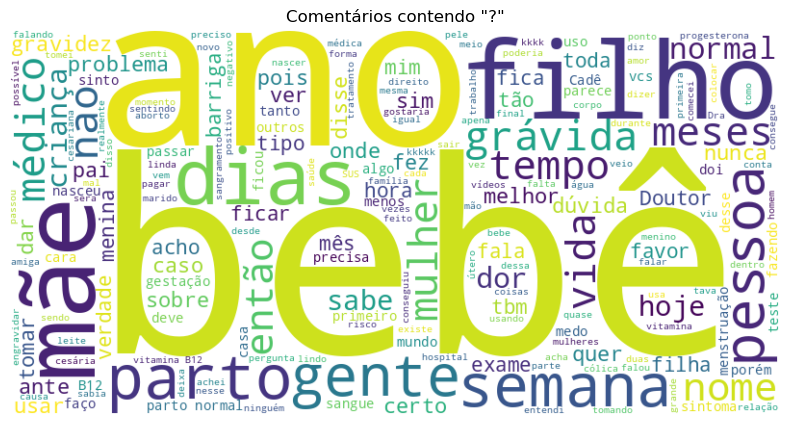

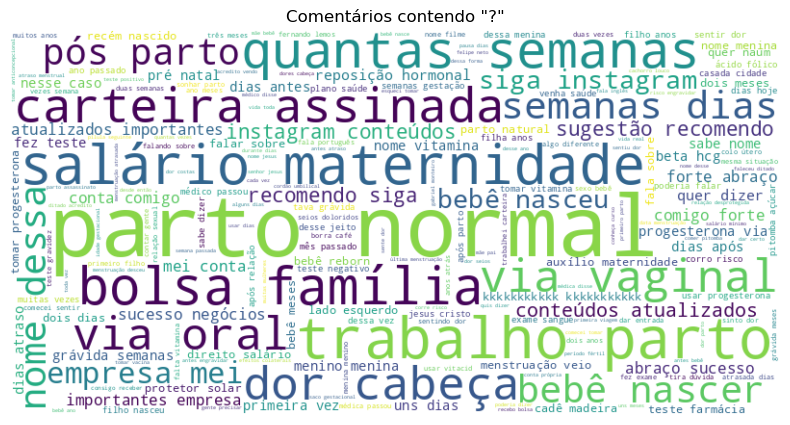

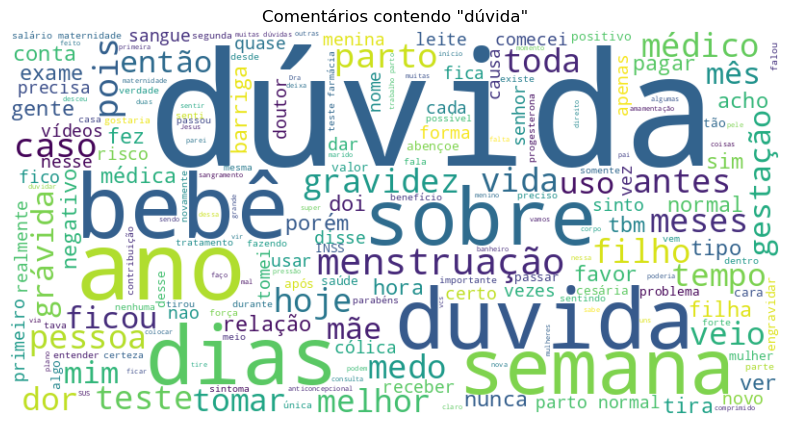

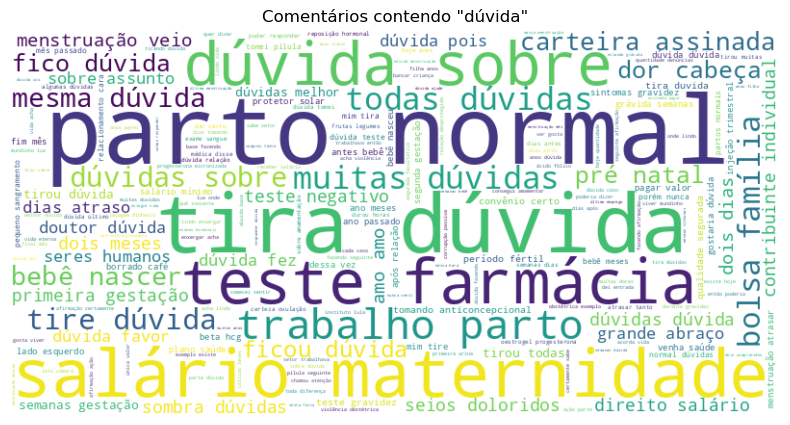

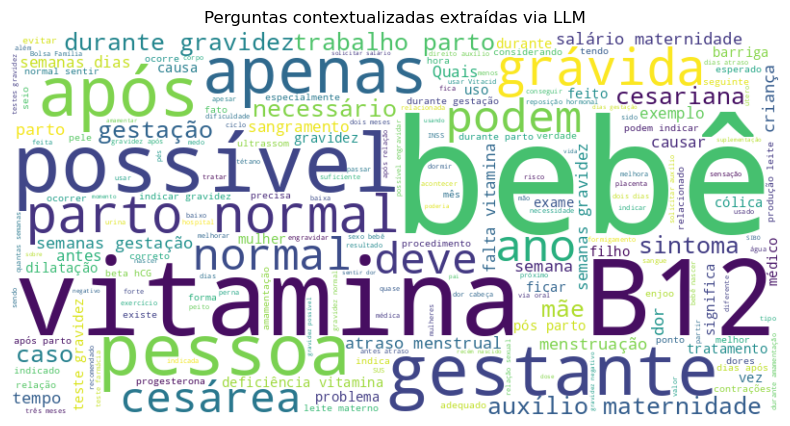

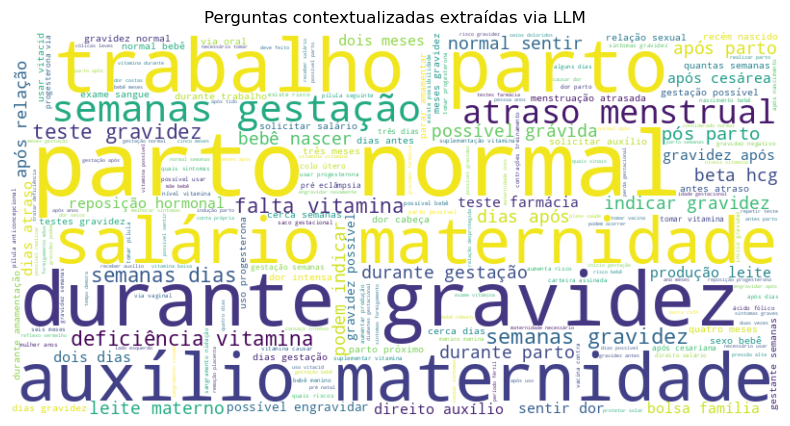

In [ ]:
for texts, title in zip([texts_interrog, texts_duv, texts_context], ['Comentários contendo "?"', 'Comentários contendo "dúvida"', 'Perguntas contextualizadas extraídas via LLM']):
    base_path = f'{FIGS_PATH}/{title}'.lower().replace(' ', '_')
    
    plot_wordcloud(texts, title, f'{base_path}_wordcloud.png')
    plot_bigram_wordcloud(texts, title, f'{base_path}_bigram.png')